# LISA Galactic population analysis

In this demo we will look at the signal-to-noise ratio (SNR) as an indicator of detectability of Galactic LISA sources but highlight some issues with how this is often calculated.

We will then look at the properties of of the detected sources based on the model galaxy of Korol et al. (2017) and assess how well they represent the underlying population.

Before we start we need to install and load some packages and tools and retrieve a file with the population data **[this will take some time!]**



In [3]:
!pip install -q GBGPU
!pip install -q --force-reinstall --no-deps \ git+https://github.com/lisa-analysis-tools/GPUBackendTools.git
!git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git
!pip install -q --force-reinstall --no-deps ./lisa-analysis-tools
!pip install lisaorbits astropy legwork galpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Cloning into 'lisa-analysis-tools'...
remote: Enumerating objects: 27752, done.
remote: Counting objects: 100% (1173/1173), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 27752 (delta 1082), reused 1085 (delta 1028), pack-reused 26579 (from 2)
Receiving objects: 100% (27752/27752), 154.52 MiB | 17.50 MiB/s, done.
Resolving deltas: 100% (19577/19577), done.
  Installing build dependencies ... done
  Getti

In [4]:
!wget -q https://raw.githubusercontent.com/nelemans/LISA_GB_Population/main/SNRFiltered.csv


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm

from astropy import units as u
import astropy.coordinates as coord
from galpy.util.coords import lb_to_radec

import pandas as pd
import seaborn as sns
import legwork as lw

from lisatools.stochastic import StochasticContribution
import lisatools.detector as lisa_models
from lisatools.detector import Orbits
from lisatools.utils.constants import *
from gbgpu.gbgpu import GBGPU
from lisatools.sensitivity import AE1SensitivityMatrix

import os


DEBUG:gpubackendtools:Configuration file not found in '/content/gpubackendtools.ini'
DEBUG:gpubackendtools:Configuration file not found in '/root/.config/gpubackendtools.ini'
DEBUG:gpubackendtools:Configuration file not found in '/etc/xdg/gpubackendtools/v0.1/gpubackendtools.ini'
DEBUG:gpubackendtools:ConfigInitialization: final configuration entries are
DEBUG:gpubackendtools: ignore_cfg=False (from: ConfigSource.DEFAULT)
DEBUG:gpubackendtools: ignore_env=False (from: ConfigSource.DEFAULT)
DEBUG:gpubackendtools: config_file=None (from: ConfigSource.DEFAULT)
DEBUG:gpubackendtools: log_level=30 (from: ConfigSource.DEFAULT)
DEBUG:gpubackendtools: log_format=None (from: ConfigSource.DEFAULT)
DEBUG:gpubackendtools: enabled_backends=None (from: ConfigSource.DEFAULT)


In [6]:
# SNR_Angles code
class KarnesisGalacticForeground(StochasticContribution):
    """Hyperbolic Tangent-based foreground fitting function."""

    ndim = 5
    def specific_Sh_function(
        f: float | np.ndarray, T: float
    ) -> float | np.ndarray:
        """Karn

        This model for the PSD contribution from the observation-time dependent galactic foreground, as computed in https://link.aps.org/accepted/10.1103/PhysRevD.104.04301.

        Args:
            f: Frequency array.
            T: Observation time in years.

        Returns:
            PSD of the Galaxy foreground noise along the frequencies f.

        """

        a_1 = -0.15
        a_k = -0.37
        b1 = -2.72
        bk = -2.49
        amp = 1.15e-44
        f2 = 0.00067
        alpha = 1.56

        f1 = T**(a_1) * 10**b1
        fk = T**(a_k) * 10**bk
        Sgal = (
            amp
            * np.exp(-(f/f1)**alpha)
            * (f ** (-7.0 / 3.0))
            * 0.5
            * (1.0 + np.tanh(-(f - fk)/f2))
        )
        return Sgal



class LISADetector():
    def __init__(self, dt=10, Tobsyr=4, orbit = "EqualArmLength", stochastic = KarnesisGalacticForeground, SensMat = AE1SensitivityMatrix, model = lisa_models.scirdv1):
        self.dt = dt
        self.Tobsyr = Tobsyr
        self.Tobs = int((Tobsyr * YRSID_SI)/dt)*dt

        if not os.path.exists(f"EqualArmLength"):
            from lisaorbits import EqualArmlengthOrbits
            orbitclass = EqualArmlengthOrbits()
            dt = 100000 #Time cadence for orbital samples: can be broad
            Torbit = 4.5*YRSID_SI #Should be bigger than Tobsyr!
            size = int(Torbit/dt)
            orbitclass.write(orbit, dt=dt, size=size)

        from lisaorbits import EqualArmlengthOrbits

        self.orbit = orbit
        self.stochastic = stochastic
        self.SensMat = SensMat
        self.model = model

        lisatoolsOrbit = Orbits(self.orbit)
        self.gb = GBGPU(force_backend="cpu", orbits=lisatoolsOrbit)

        if self.stochastic is not None:
            self.PSDfunc =  lambda f: self.SensMat(f, model=self.model, return_type='PSD', stochastic_function=self.stochastic, stochastic_kwargs={'T' : self.Tobsyr}).sens_mat
        else:
            self.PSDfunc = lambda f: self.SensMat(f, model=self.model, return_type='PSD').sens_mat

    def PSD_func(self, channel='multichannel', **kwargs):
        if channel=='multichannel':
            return self.PSDfunc
        else:
            return lambda f: self.PSDfunc(f)[0,:]

    def compute_PSD(self, fgrid, channel='multichannel',  **kwargs):
        if channel=='multichannel':
            PSDvals = self.PSDfunc(fgrid)
        else:
            PSDvals = self.PSDfunc(fgrid)[0,:]

        return PSDvals

    def get_wavegen(self):
        return self.gb

    def SNR(self,pars):
        '''
        pars: (A, f, fdot, fddot, phase, inclination, psi, lam, beta)
        where
        A = 2*(pi f)**(2/3) * (GM_ch)^(5/3)/(c^4 * D)
        f is the GW frequency (2/P_orb) at a fiducial time in the orbit
        fdot is the change in the GW frequency: 96/5 * np.pi**(8/3) * (G*Mch)**(5/3) * f**(11/3) / (c**5)
        fddot is the second order derivative in GW frequency
        phase refers to the phase at the fiducial time
        inclination between 0 and pi; the viewing angle from the right-handed north pole of the binary
        psi between 0 and pi the relation between the polarization basis in source and detectors frame
        lam,beta are longitude/latitude in ecliptic coordinates

        '''
        gb = self.gb
        gb.run_wave(*pars, T=self.Tobs, dt=self.dt)
        df = 1/self.Tobs
        fgrid = self.gb.freqs[0]
        A = gb.A[0]
        E = gb.E[0]
        PSDvals = self.compute_PSD(fgrid)

        SNR2 = (
            4
            * df
            * np.sum(
                (A.conj() * A).real / PSDvals[0, :]
            )
        ) + (
            4
            * df
            * np.sum(
                (E.conj() * E).real / PSDvals[1, :]
            )
        )

        return np.sqrt(SNR2)


@u.quantity_input(Mch=u.kg, f=u.Hz, D=u.m)
def Amp(Mch, f, D):
    #Input: astropy units of appropriate dimension
    #Output: amplitude value.
    G = G_SI * (u.m)**3 * (u.kg)**(-1) * (u.s)**(-2)
    c = C_SI * u.m/u.s
    amp = 2*(np.pi*f)**(2/3) * (G * Mch)**(5/3) / (c**4 * D)
    return amp.to(u.dimensionless_unscaled)

@u.quantity_input(Mch=u.kg, f=u.Hz, D=u.m)
def freq_derivative(Mch, f):
    #Input: astropy units of appropriate dimension
    #Output: amplitude value.
    G = G_SI * (u.m)**3 * (u.kg)**(-1) * (u.s)**(-2)
    c = C_SI * u.m/u.s
    fdot = 96/5 * np.pi**(8/3) * (G*Mch)**(5/3) * f**(11/3) / (c**5)
    return fdot.to(u.Hz/u.s)

@u.quantity_input(f=u.Hz, fdot=u.Hz/u.s)
def chirp_mass(f,fdot):
    G = G_SI * (u.m)**3 * (u.kg)**(-1) * (u.s)**(-2)
    c = C_SI * u.m/u.s
    Mch = (1/G) * (5/96)**(3/5) * fdot**(3/5) * c**3 / (np.pi**(8/5) * f**(11/5))
    return Mch.to(u.M_sun)

@u.quantity_input(f=u.Hz, fdot=u.Hz/u.s)
def distance(A,f,fdot):
    c = C_SI * u.m/u.s
    D = 10*fdot*c/(96*np.pi**2 * f**3) * 1/A
    return D.to(u.pc)

@u.quantity_input(P=u.day, M1=u.Msun, M2=u.Msun, d = u.kpc)
def pars_to_GBGPU(P, M1, M2, d, l=0, b=0, inc = 60*u.degree, phi=0, psi=0, fddot=0, angle='galactic'):
    Mch = (M1*M2)**(3/5) / (M1+M2)**(1/5)
    f0 = (2/(P)).to(u.Hz).value
    A = Amp(Mch, f0 * u.Hz, d ).value
    fdot = freq_derivative(Mch, f0 * u.Hz).value

    from astropy.coordinates import SkyCoord, GeocentricTrueEcliptic

    c = SkyCoord(l=l*u.degree, b=b*u.degree, distance=d, frame=angle)
    ecliptic_coords = c.transform_to(GeocentricTrueEcliptic)

    lam = ecliptic_coords.lon.to(u.rad).value
    beta = ecliptic_coords.lat.to(u.rad).value

    ones = np.ones_like(A)
    pars_ref = np.array([A, f0, fdot, fddot*ones, phi*ones, inc.to(u.rad).value * ones, psi * ones, lam, beta])
    return pars_ref

    #Probably best to work with a dict-style structure tailored to the file we give.


def Mch(M1, m2):
    return (M1*m2)**0.6/(M1 + m2)**0.2

# FIM code

We will star by going back to the verification binaries, which you have seen before at the data analysis tutorial.

First: HM Cnc [ask your neighbour if you wonder why this name], with properties

```
M1 = 0.55 Msun
m2 = 0.27 Msun
P_orb = 321.5 s
f_GW = 2/P_orb = ...
d = 7.5 kpc [this is very uncertain]
inc = 38 deg
sky position (l, b) = (207,23)
```

In the cell below we have already put these values, you just have to run it.

In [7]:
# properties and position HM Cnc
P = 321.5 * u.second
M1 = 0.55 * u.Msun
M2 = 0.27 * u.Msun
d = 7.5 * u.kpc
l = 207
b = 23
inc = 38 * u.degree

# Signal to noise calculations

As you have seen in the data analysis tutorial, calculating the Signal-to-Noise ratio (SNR, not to cofuse with supernova remnant) is quite involved.

## Averaged SNR
There are ways to simply calculate this from the system parameters. Perhaps the most widely known way to do this is using the module [legwork](https://legwork.readthedocs.io/)

However, this calculated a sky-averaged, inclination averaged SNR. We will investigate how far off that is from a SNR that includes the sky position and inclination. First we calculate the SNR with legwork:

In [8]:
# initialise the legwork source with the right parameters (note you can pass either f_orb or the semi-major axis tot legwork)
sources = lw.source.Source(
    m_1=M1, m_2=M2, ecc=0, dist=d, f_orb=1/(P),
    gw_lum_tol=0.05, stat_tol=1e-2,
    interpolate_g=False, interpolate_sc=False,
    sc_params={
        "instrument": "LISA",
        "custom_psd": None,
        "t_obs": 4 * u.yr,
        "L": 2.5e9 * u.m,
        "approximate_R": False,
        "confusion_noise": "karnesis21"
    }
)

LegworkSNR = sources.get_snr(verbose=False)[0]
print(f"Legwork SNR with confusion: {LegworkSNR}")


Legwork SNR with confusion: 73.07692507098679


## SNR including the angles

Above is a slightly different implementation of calculating the SNR for a LISA instrument (with orbits) and a certain GB waveform. Below we show the basic usage and the result for HM Cnc

In [9]:
# Now we calculate the SNR including angles. For this we initiate a detector that is LISA and explicitly pass the observing time

det = LISADetector(Tobsyr=4)

# the SNR is a function of the class. We only have to pass the right parameters,
# for which there is a special function that takes the parameters
# as we have defined them
AnglesSNR = det.SNR(pars_to_GBGPU(P,M1,M2,d,l,b,inc))
print(f"Angles SNR with confusion: {AnglesSNR}")

Angles SNR with confusion: 94.99092882046527


You can see the difference. Please play with the parameters to see the effect of the angles. Inclination close to 90 degrees is interesting to explore as well as different sky positions (inspired by the results of the data analysis tutorial perhaps, but be careful, here we work in Galactic coordinates, while there we use ecliptic coordinates

# A population of LISA Galactic Binaries

We now turn to a simulated population of Galactic Binaries. Is is the one presented in Korol et al. (2017) and is based on the SeBa population synthesis code (Nelemans et al., 2001, Toonen et al. 2012). It distributes the sources in the Galaxy using a model for how the star formation evolved over time, but also place within the Galaxy. It includes a single Galactic disk (with no spiral arms) and a Bulge. We provide a file with all sources that could be detectable, which we define here as either having a legwork SNR > 7 or a angles included SNR > 7.

The file contains the following columns
| Name | meaning | unit |
|--|--|--|
| Mchirp | Chirp mass | Msun|
| f_GW | GW frequency (2/P_orb) | mHz(!)|
| l | Galactic longitude | ? |
| b | Galactic latitude | ?|
| inclination | | ?|
| distance | distance | kpc |
| Rmag | EM brightness | magnitude |
| LegworkSNR | ||
| AnglesSNR ||



## Exploring the data and potential bias of using Legwork

Below we read in the data. Please explore the effect of the different SNR calculation by plotting histograms (or as our math colleagues often point out, better use a Kernel Density Estimate, KDE) of the inclination, chirp mass and sky position for the population based on the Legwork cut only and for the population bases on the angles SNR only [hint use a mask]

In [10]:
# read data file
data = pd.read_csv('SNRFiltered.csv')

# define the masks
maskLegwork = data['approxSNR'] > 7
maskAngles = data['exactSNR'] > 7




In [12]:
data['Mchirp'] = Mch(data['M1'],data['M2'])

In [143]:
data['Mtot'] = data['M1']+data['M2']

In [83]:
np.array(data['l'])*u.degree

<Quantity [-35.328  ,   1.03346,   1.57891, ..., 136.293  ,  -8.77634,
            25.4323 ] deg>

In [84]:
from astropy.coordinates import SkyCoord
c = SkyCoord(l=np.array(data['l'])*u.degree, b=np.array(data['b'])*u.degree, distance = np.array(data['d'])*u.kpc, frame='galactic')
gal_d = c.transform_to(frame='galactocentric').spherical.distance.value
print(gal_d)

[6.63914836 0.29451718 0.84997512 ... 9.00200286 6.67707168 7.71955998]


In [85]:
data['gal_d'] = gal_d

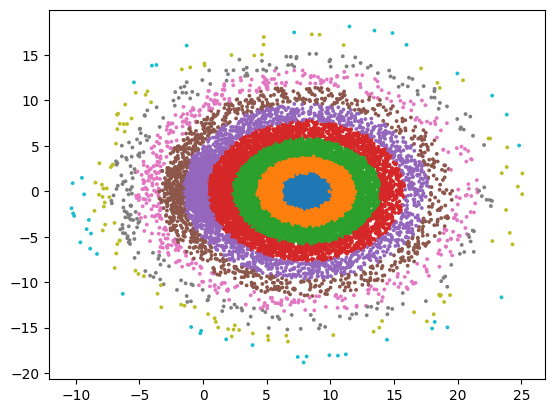

In [124]:
plt.scatter(data['d']*np.cos(data['l']/57.3),data['d']*np.sin(data['l']/57.3),c=data['gal_d'],s=3,alpha=1,cmap='tab10')

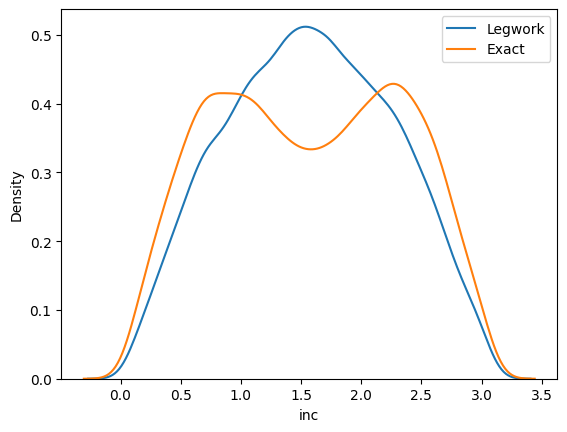

In [11]:
# plot historgrams/KDE for population with SNR_Legwork > 7 and SNR_Angles > 7, Mchirp, inclination, sky position
sns.kdeplot(data[maskLegwork],x='inc',label='Legwork')
sns.kdeplot(data[maskAngles],x='inc',label='Exact')
plt.legend()
plt.show()

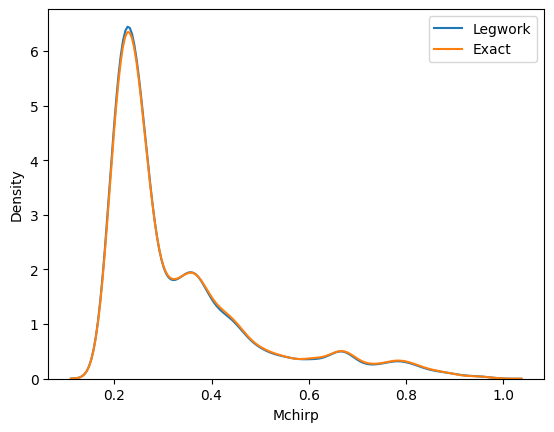

In [13]:
sns.kdeplot(data[maskLegwork],x='Mchirp',label='Legwork')
sns.kdeplot(data[maskAngles],x='Mchirp',label='Exact')
plt.legend()
plt.show()

<Axes: xlabel='Mchirp', ylabel='Density'>

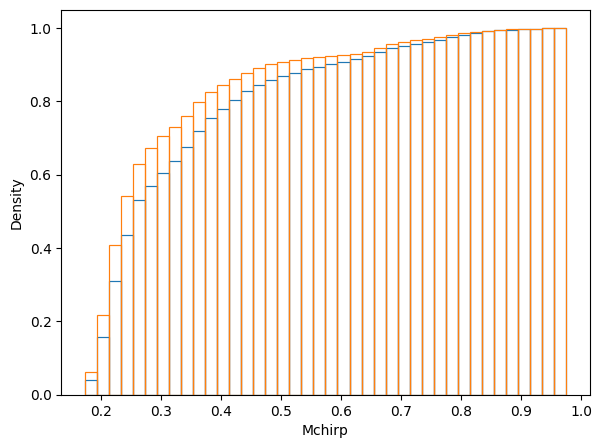

In [142]:
mask = (data['exactSNR'] > 7) & (data['gal_d'] < 3) & (data['gal_d'] > 0)
mask2 = (data['exactSNR'] > 7) & (data['d'] < 20)
fig = plt.figure(figsize=(15, 5))
plt.subplot(121)
sns.histplot(data[mask2],x='Mchirp',bins=40,fill=False,stat='density',cumulative=True)



#plt.subplot(122)
sns.histplot(data[mask],x='Mchirp',bins=40,fill=False,stat='density',cumulative=True)

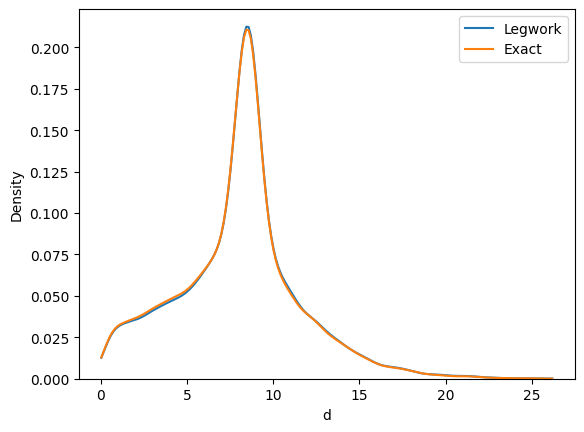

In [21]:
sns.kdeplot(data[maskLegwork],x='d',cut=0,label='Legwork')
sns.kdeplot(data[maskAngles],x='d',cut=0,label='Exact')
plt.legend()
plt.show()

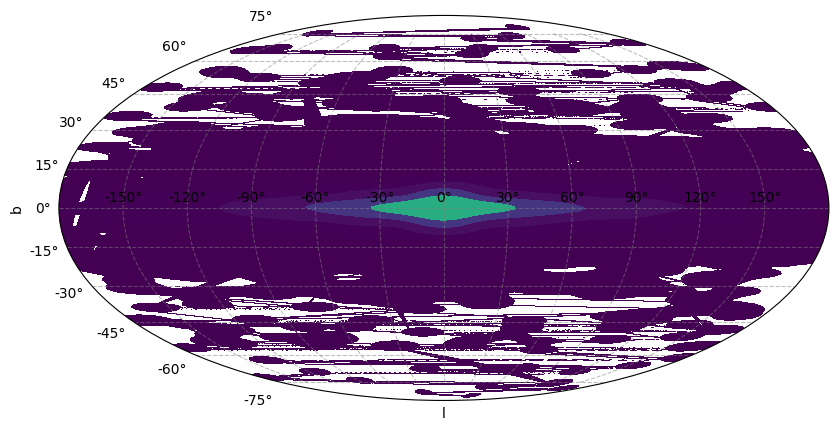

In [18]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')
log_levels = np.geomspace(0.001, 1.0, num=10)

# 4. Plot the KDE using seaborn, passing the explicit axis object
sns.kdeplot(
    x=data[maskLegwork]['l']/57.3,
    y=data[maskLegwork]['b']/57.3,
    ax=ax,
    fill=True,
    thresh=0.0,
    levels=log_levels,
    cmap="viridis"
)

# 5. Format the grid and appearance
ax.grid(True, color='gray', linestyle='--', alpha=0.5)

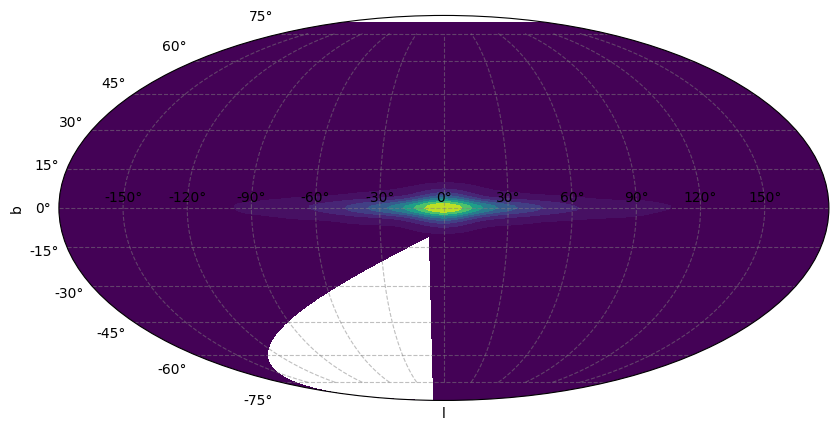

In [46]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

# 4. Plot the KDE using seaborn, passing the explicit axis object
sns.kdeplot(
    x=data[maskAngles]['l']/57.3,
    y=data[maskAngles]['b']/57.3,
    ax=ax,
    fill=True,
    thresh=0.0,
    levels=10,
    cmap="viridis"
)

# 5. Format the grid and appearance
ax.grid(True, color='gray', linestyle='--', alpha=0.5)

<Axes: xlabel='Mchirp', ylabel='d'>

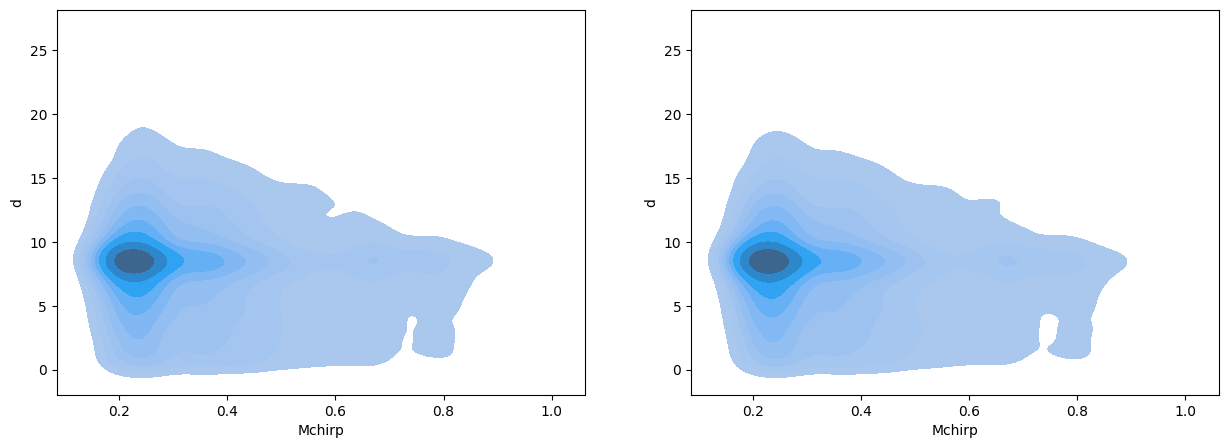

In [29]:
log_levels = np.geomspace(0.0000001, 1, num=10)
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(121)
sns.kdeplot(data[maskLegwork],x='Mchirp',y='d',fill=True)
plt.xlim([0,18])

ax = fig.add_subplot(122)
sns.kdeplot(data[maskAngles],x='Mchirp',y='d',fill=True)
plt.xlim([0,18])

(0.0, 12.0)

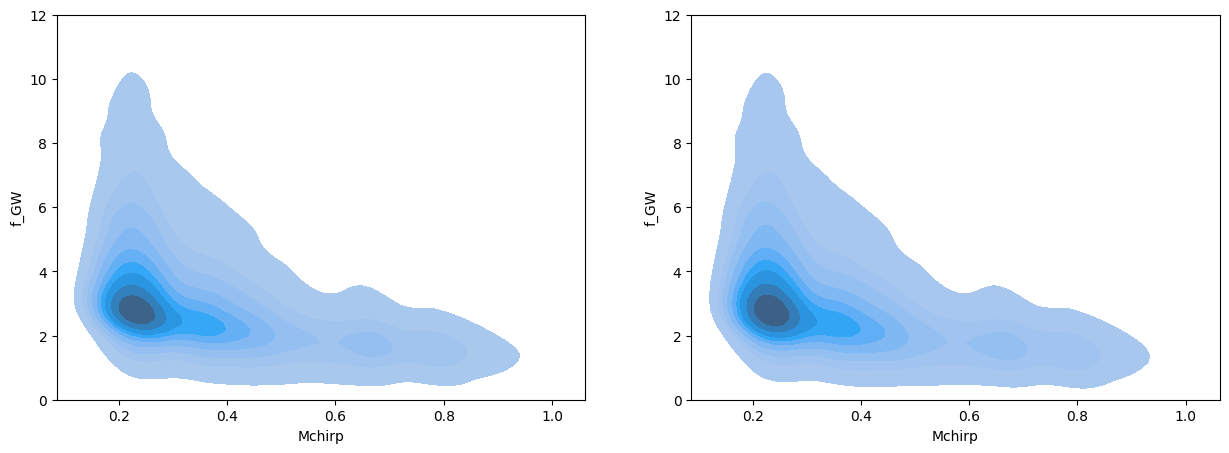

In [43]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(121)
sns.kdeplot(data[maskLegwork],x='Mchirp',y='f_GW',fill=True)
plt.ylim([0,12])

ax = fig.add_subplot(122)
sns.kdeplot(data[maskAngles],x='Mchirp',y='f_GW',fill=True)
plt.ylim([0,12])

(0.0, 18.0)

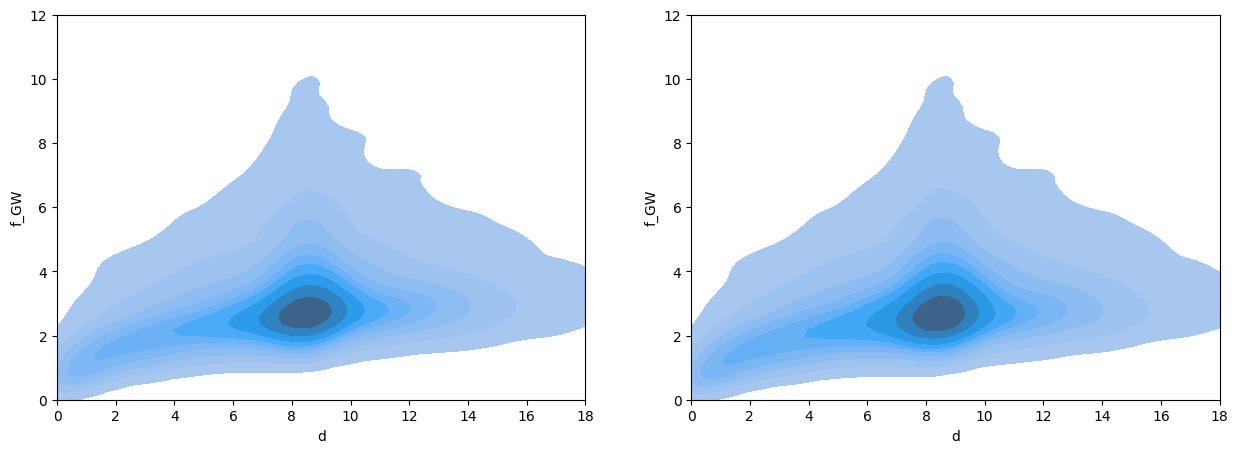

In [44]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(121)
sns.kdeplot(data[maskLegwork],x='d',y='f_GW',fill=True)
plt.ylim([0,12])
plt.xlim([0,18])

ax = fig.add_subplot(122)
sns.kdeplot(data[maskAngles],x='d',y='f_GW',fill=True)
plt.ylim([0,12])
plt.xlim([0,18])

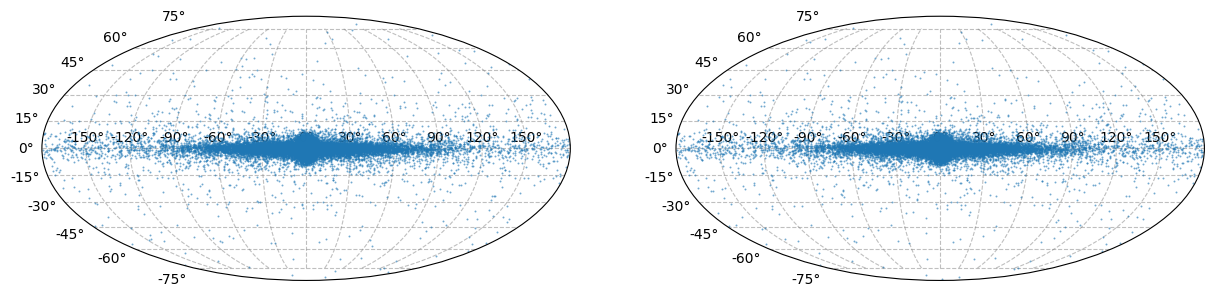

In [61]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(121, projection='mollweide')

ax.plot(data[maskLegwork]['l']/57.3,data[maskLegwork]['b']/57.3,'s',markersize=0.5,alpha=0.5)

ax.grid(True, color='gray', linestyle='--', alpha=0.5)

ax = fig.add_subplot(122, projection='mollweide')

ax.plot(data[maskAngles]['l']/57.3,data[maskAngles]['b']/57.3,'s',markersize=0.5,alpha=0.5)

ax.grid(True, color='gray', linestyle='--', alpha=0.5)



In [37]:
data.keys()

Index(['Unnamed: 0', 'id', 'M1', 'M2', 'P', 'l', 'b', 'd', 'inc', 'R1', 'R2',
       'g_mag1', 'r_mag1', 'g_mag2', 'r_mag2', 'exactSNR', 'approxSNR'],
      dtype='object')

In [31]:
data['P']

,P
0,0.013673
1,0.011211
2,0.010098
3,0.007525
4,0.004801
...,...
27493,0.009882
27494,0.004553
27495,0.026265
27496,0.022624


## The cirp mass disstribution

For the rest of the session we will be looking at the chirp-mass distriution ofthe detected sources and investigate if that is representative of the underlying poplation. And if not, if we can do something to remedy that. Include plot of overall chirp-mass distribution

In [ ]:
# Make plots of chirp mass distribution of detected sources SNR_Angles > 7. Does it look like general distributon?

We expect the detected population to consist of especially strong sources near the Galactic center (where the density of sources is very high) plus a population of sources that are nearby. Plot the chirp-mass distibution for sources nearby (d < 2 kpc) and check if that corresponds better with the underlying chirp-mass distribution

In [ ]:
#mask points with d < 2kpc and plot again

However, we forget one thing: in order to do the above, we need to be able to measure both the distance and chirp mass well. Since for a monochromatic source, we measure the amplitude of the wave (which depends on the chirp mass and the distance), this is not obvious. We can make a quick estimate of the expected measurement uncertainty using the fisher matrix method

In [ ]:
# calculate FIM and uncertainties for verification binary.

We calculated the uncertainties in chirp mass and distance for you and they are included already in the data frame. If we limit the population to sources with relative uncertainties in chirp mass and distance of 10%, determine how many sources are left and plot the inferred chirp mass distributions both for the sample with all distances and the sample with d < 1 kpc

In [ ]:
# code

(0.0, 12.0)

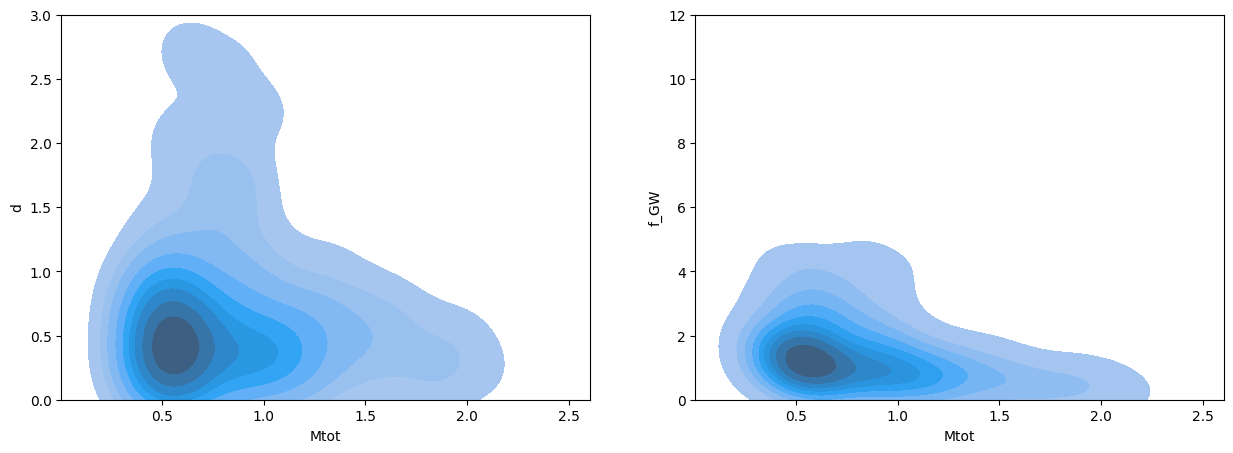

In [155]:
#Total mass
mask = (data['exactSNR'] > 7) & (data['g_mag2'] < 21)
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(121)
sns.kdeplot(data[mask],x='Mtot',y='d',fill=True)
plt.ylim([0,3])

ax = fig.add_subplot(122)
sns.kdeplot(data[mask],x='Mtot',y='f_GW',fill=True)
plt.ylim([0,12])

In [170]:
mask = (data['exactSNR'] > 7) & (data['f_GW'] < 50) & (data['g_mag2'] < 21)
len(data[mask])

299